In [11]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Satıcılar

🎯 Amacımız, diğerlerine göre tekrarlı olarak düşük performans gösteren satıcıları bulmak ve nedenini anlamaktır.  
Bu, Olist'in gelecekte kâr marjını artırmaya yönelik önerilerimizi şekillendirmemize yardımcı olacaktır.

## 1 - `olist/seller.py`  

`order.py` ile benzer bir süreçte, size `olist/seller.py` modülünü sunduk; içinde `Seller` sınıfı ve `Seller().get_training_data` yöntemi bulunuyor. Bu yöntem aşağıdaki özellikleri içeren bir DataFrame döndürür:

| feature_name | type | açıklama |
| --- | --- | --- |
| `seller_id` | str | satıcının benzersiz kimliği (UNIQUE) |
| `seller_city` | str | satıcının bulunduğu şehir |
| `seller_state` | str | satıcının bulunduğu eyalet |
| `delay_to_carrier` | float | sipariş, `shipping_limit_date`'den önce teslim edildiyse 0 döner; aksi takdirde gecikme süresini verir |
| `wait_time` | float | satıcı başına ortalama teslimat süresi (bekleme süresi) |
| `date_first_sale` | datetime | Olist üzerinde yapılan ilk satışın tarihi |
| `date_last_sale` | datetime | Olist üzerindeki son satışın tarihi |
| `months_on_olist` | float | Olist'te geçirilen yaklaşık ay sayısı |
| `share_of_five_stars` | float | satıcının yer aldığı siparişlerdeki beş yıldız değerlendirmelerinin oranı |
| `share_of_one_stars` | float | satıcının yer aldığı siparişlerdeki bir yıldız değerlendirmelerinin oranı |
| `review_score` | float | satıcının yer aldığı siparişler için ortalama değerlendirme puanı |
| `n_orders` | int | satıcının yer aldığı benzersiz sipariş sayısı |
| `quantity` | int | bu satıcı tarafından satılan toplam ürün adedi |
| `quantity_per_order` | float | bu satıcı için sipariş başına ortalama ürün sayısı |
| `sales` | float | bu satıcı ile ilişkili toplam satış tutarı (kargo hariç), BRL cinsinden |

❓ **Aşağıya yeni sınıfınızı import edin ve eğitim veri çerçevenizi inceleyin!** Kodları incelemek için zaman ayırın ve sizin için tam olarak nelerin hesaplandığını anlayın.

In [12]:
from olist.seller import Seller

seller = Seller()
training_data = seller.get_training_data()

training_data.head()

,seller_id,seller_city,seller_state,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,share_of_one_stars,share_of_five_stars,review_score,n_orders,quantity,quantity_per_order,sales
0,3442f8959a84dea7ee197c632cb2df15,campinas,SP,0.000000,13.018588,2017-05-05 16:25:11,2017-08-30 12:50:19,4.0,0.333333,0.333333,3.00,3,3,1.000,218.70
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,SP,0.000000,9.065716,2017-03-29 02:10:34,2018-06-06 20:15:21,14.0,0.050000,0.725000,4.55,40,41,1.025,11703.07
2,ce3ad9de960102d0677a81f5d0bb7b2d,rio de janeiro,RJ,0.000000,4.042292,2018-07-30 12:44:49,2018-07-30 12:44:49,0.0,0.000000,1.000000,5.00,1,1,1.000,158.00
3,c0f3eea2e14555b6faeea3dd58c1b1c3,sao paulo,SP,0.000000,5.667187,2018-08-03 00:44:08,2018-08-03 00:44:08,0.0,0.000000,1.000000,5.00,1,1,1.000,79.99
4,51a04a8a6bdcb23deccc82b0b80742cf,braganca paulista,SP,3.353727,35.314861,2017-11-14 12:15:25,2017-11-14 12:15:25,0.0,1.000000,0.000000,1.00,1,1,1.000,167.99


In [13]:
training_data.sort_values(
    by=["share_of_one_stars", "review_score", "delay_to_carrier"],
    ascending=[False, True, False]
).head(20)

,seller_id,seller_city,seller_state,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,share_of_one_stars,share_of_five_stars,review_score,n_orders,quantity,quantity_per_order,sales
2904,586a871d4f1221763fddb6ceefdeb95e,porto alegre,RS,45.434039,68.621146,2017-01-28 04:35:50,2017-01-28 04:35:50,0.0,1.0,0.0,1.0,1,2,2.000000,198.00
1113,87f3e35268860433e13d577825aada95,bom jesus dos perdoes,SP,41.316146,51.497106,2016-10-07 02:48:26,2017-06-17 03:26:40,8.0,1.0,0.0,1.0,3,3,1.000000,161.70
2178,8e670472e453ba34a379331513d6aab1,juiz de fora,MG,40.150509,86.001169,2017-09-06 17:15:12,2017-09-06 17:15:12,0.0,1.0,0.0,1.0,1,1,1.000000,975.00
2747,6d04126aba80df143fd038e711b8fd96,rio de janeiro,RJ,26.873634,37.079167,2017-09-08 15:03:27,2017-09-08 15:03:27,0.0,1.0,0.0,1.0,1,1,1.000000,89.99
1185,244b04680fdbded0acf5aebd9c92b44a,jundiai,SP,23.725307,38.014931,2017-12-12 11:12:18,2018-03-28 21:35:14,4.0,1.0,0.0,1.0,3,3,1.000000,3477.70
1897,8d92f3ea807b89465643c219455e7369,sao paulo,SP,21.521911,42.115906,2017-01-25 16:45:21,2017-03-03 02:22:26,1.0,1.0,0.0,1.0,3,8,2.666667,121.20
958,8629a7efec1aab257e58cda559f03ba7,goiania,GO,19.313889,59.226678,2018-02-16 14:10:29,2018-02-16 14:10:29,0.0,1.0,0.0,1.0,1,1,1.000000,45.22
957,c004e5ea15737026cecaee0447e00b75,sao paulo,SP,18.517870,33.831701,2018-08-06 11:15:27,2018-08-10 00:30:16,0.0,1.0,0.0,1.0,2,2,1.000000,4700.00
2371,d1a5cc844736958c11b8efab9a2b4c87,curitiba,PR,18.387951,30.294271,2017-10-23 13:25:52,2017-10-23 13:25:52,0.0,1.0,0.0,1.0,1,1,1.000000,237.60
770,3da38366e7bd9baf6369071f782ecdf0,fortaleza,CE,16.507477,53.348426,2018-01-05 02:37:56,2018-01-05 02:37:56,0.0,1.0,0.0,1.0,1,1,1.000000,59.47


In [14]:
from olist.seller import Seller

seller = Seller()
training_data = seller.get_training_data()
training_data.head()

,seller_id,seller_city,seller_state,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,share_of_one_stars,share_of_five_stars,review_score,n_orders,quantity,quantity_per_order,sales
0,3442f8959a84dea7ee197c632cb2df15,campinas,SP,0.000000,13.018588,2017-05-05 16:25:11,2017-08-30 12:50:19,4.0,0.333333,0.333333,3.00,3,3,1.000,218.70
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,SP,0.000000,9.065716,2017-03-29 02:10:34,2018-06-06 20:15:21,14.0,0.050000,0.725000,4.55,40,41,1.025,11703.07
2,ce3ad9de960102d0677a81f5d0bb7b2d,rio de janeiro,RJ,0.000000,4.042292,2018-07-30 12:44:49,2018-07-30 12:44:49,0.0,0.000000,1.000000,5.00,1,1,1.000,158.00
3,c0f3eea2e14555b6faeea3dd58c1b1c3,sao paulo,SP,0.000000,5.667187,2018-08-03 00:44:08,2018-08-03 00:44:08,0.0,0.000000,1.000000,5.00,1,1,1.000,79.99
4,51a04a8a6bdcb23deccc82b0b80742cf,braganca paulista,SP,3.353727,35.314861,2017-11-14 12:15:25,2017-11-14 12:15:25,0.0,1.000000,0.000000,1.00,1,1,1.000,167.99


In [15]:
import importlib
import olist.seller

importlib.reload(olist.seller)

from olist.seller import Seller

seller = Seller()
seller.get_review_score().head()

,seller_id,share_of_one_stars,share_of_five_stars,review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,0.333333,0.666667,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,0.121827,0.527919,3.984772
2,001e6ad469a905060d959994f1b41e4f,1.000000,0.000000,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,0.134615,0.519231,3.903846
4,003554e2dce176b5555353e4f3555ac8,0.000000,1.000000,5.000000


🤔 Her satıcı için henüz hesaplanması gereken bir şey kaldı:
- Aşırı yüksek değerlendirmelerin oranı (`share_of_five_stars`) ve aşırı düşük değerlendirmelerin oranı (`share_of_one_stars`)
- (ortalama) `review_score`

😱 Düşük puanlı her sipariş Olist'in itibarına olumsuz etki yapar; bu etki `cost_of_review` ile modellenir.

Bu, daha sonra her satıcı için toplam `cost_of_review`'u hesaplamamıza yardımcı olacak!

❓ **Sizin doldurmanız gereken son metod: `get_review_score()`'u implemente edin.**

In [16]:
seller = Seller()
seller.get_review_score()

,seller_id,share_of_one_stars,share_of_five_stars,review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,0.333333,0.666667,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,0.121827,0.527919,3.984772
2,001e6ad469a905060d959994f1b41e4f,1.000000,0.000000,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,0.134615,0.519231,3.903846
4,003554e2dce176b5555353e4f3555ac8,0.000000,1.000000,5.000000
...,...,...,...,...
3085,ffcfefa19b08742c5d315f2791395ee5,1.000000,0.000000,1.000000
3086,ffdd9f82b9a447f6f8d4b91554cc7dd3,0.055556,0.666667,4.333333
3087,ffeee66ac5d5a62fe688b9d26f83f534,0.142857,0.642857,4.214286
3088,fffd5413c0700ac820c7069d66d98c89,0.186441,0.542373,3.847458


🧪 Kodunuzu aşağıda test edin

In [17]:
from nbresult import ChallengeResult

tmp = Seller().get_training_data()
result = ChallengeResult('seller',
    shape = tmp.shape,
    median = tmp.review_score.median(),
    columns = tmp.columns
)
result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.13.13, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\BÜŞRA\AppData\Local\Programs\Python\Python313\python.exe
cachedir: .pytest_cache
rootdir: d:\DOSYALARIM\workintech gh\data-sellers-main\tests
plugins: anyio-4.13.0, dash-4.4.1
collecting ... collected 3 items

test_seller.py::TestSeller::test_column_names PASSED                     [ 33%]
test_seller.py::TestSeller::test_median_review_score PASSED              [ 66%]
test_seller.py::TestSeller::test_shape PASSED                            [100%]

============================== 3 passed in 0.92s ==============================


💯 You can commit your code:

git add tests/seller.pickle

git commit -m 'Completed seller step'

git push origin master



💡 **Tam satır sayısını elde edemiyor musunuz?**
<details><summary>Fazladan 3 satır mı var?</summary>
Left veya right join mi yaptınız? Nedenini anlıyoruz; fakat burada sadece değerlendirme alan satıcılarla ilgileniyoruz; bu yüzden inner join kullandık.
</details>
<details><summary>2 satır mı eksik?</summary>
`Orders().get_training_data()`'ı mı kullandınız? Bu geçerli bir seçenek, fakat sadece değerlendirmelerle ilgileniyorsak biraz aşırı olabilir. O method birçok hesaplama yapar ve döndürdüğü sütunların çoğuna ihtiyaç duymuyoruz. İhtiyacımıza daha uygun başka bir `Order` methodu bulun.
</details>

⚠️ `olist` reposundaki `seller.py` dosyasına yaptığınız kod değişikliklerini commit etmeyi unutmayın!

## 2 - Satıcıları İnceleme

### (2.1) Görselleştirmeler

Bu satıcılar hakkında ilk ***`EDA - Keşifsel Veri Analizi`*** ile başlayalım.

👉 `sellers` için özet istatistiklere bakın. Satıcı başına siparişlerin medyanı nedir ❓

In [18]:
training_data.sort_values(
    by=["share_of_one_stars", "review_score", "delay_to_carrier"],
    ascending=[False, True, False]
).head(20)

,seller_id,seller_city,seller_state,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,share_of_one_stars,share_of_five_stars,review_score,n_orders,quantity,quantity_per_order,sales
2904,586a871d4f1221763fddb6ceefdeb95e,porto alegre,RS,45.434039,68.621146,2017-01-28 04:35:50,2017-01-28 04:35:50,0.0,1.0,0.0,1.0,1,2,2.000000,198.00
1113,87f3e35268860433e13d577825aada95,bom jesus dos perdoes,SP,41.316146,51.497106,2016-10-07 02:48:26,2017-06-17 03:26:40,8.0,1.0,0.0,1.0,3,3,1.000000,161.70
2178,8e670472e453ba34a379331513d6aab1,juiz de fora,MG,40.150509,86.001169,2017-09-06 17:15:12,2017-09-06 17:15:12,0.0,1.0,0.0,1.0,1,1,1.000000,975.00
2747,6d04126aba80df143fd038e711b8fd96,rio de janeiro,RJ,26.873634,37.079167,2017-09-08 15:03:27,2017-09-08 15:03:27,0.0,1.0,0.0,1.0,1,1,1.000000,89.99
1185,244b04680fdbded0acf5aebd9c92b44a,jundiai,SP,23.725307,38.014931,2017-12-12 11:12:18,2018-03-28 21:35:14,4.0,1.0,0.0,1.0,3,3,1.000000,3477.70
1897,8d92f3ea807b89465643c219455e7369,sao paulo,SP,21.521911,42.115906,2017-01-25 16:45:21,2017-03-03 02:22:26,1.0,1.0,0.0,1.0,3,8,2.666667,121.20
958,8629a7efec1aab257e58cda559f03ba7,goiania,GO,19.313889,59.226678,2018-02-16 14:10:29,2018-02-16 14:10:29,0.0,1.0,0.0,1.0,1,1,1.000000,45.22
957,c004e5ea15737026cecaee0447e00b75,sao paulo,SP,18.517870,33.831701,2018-08-06 11:15:27,2018-08-10 00:30:16,0.0,1.0,0.0,1.0,2,2,1.000000,4700.00
2371,d1a5cc844736958c11b8efab9a2b4c87,curitiba,PR,18.387951,30.294271,2017-10-23 13:25:52,2017-10-23 13:25:52,0.0,1.0,0.0,1.0,1,1,1.000000,237.60
770,3da38366e7bd9baf6369071f782ecdf0,fortaleza,CE,16.507477,53.348426,2018-01-05 02:37:56,2018-01-05 02:37:56,0.0,1.0,0.0,1.0,1,1,1.000000,59.47


In [21]:
sellers = training_data.copy()

sellers['n_orders'].median()

np.float64(7.0)

👉 Bir sonraki adımda, veri setindeki her sayısal değişkenin dağılımını tek bir büyük görselde çizeceğiz. 

Kod size verildi, hücreyi çalıştırmanız yeterli.

- 👀 Herhangi bir aykırı değer fark ediyor musunuz?
- Sipariş sayısının dağılımı nasıl görünüyor ❓

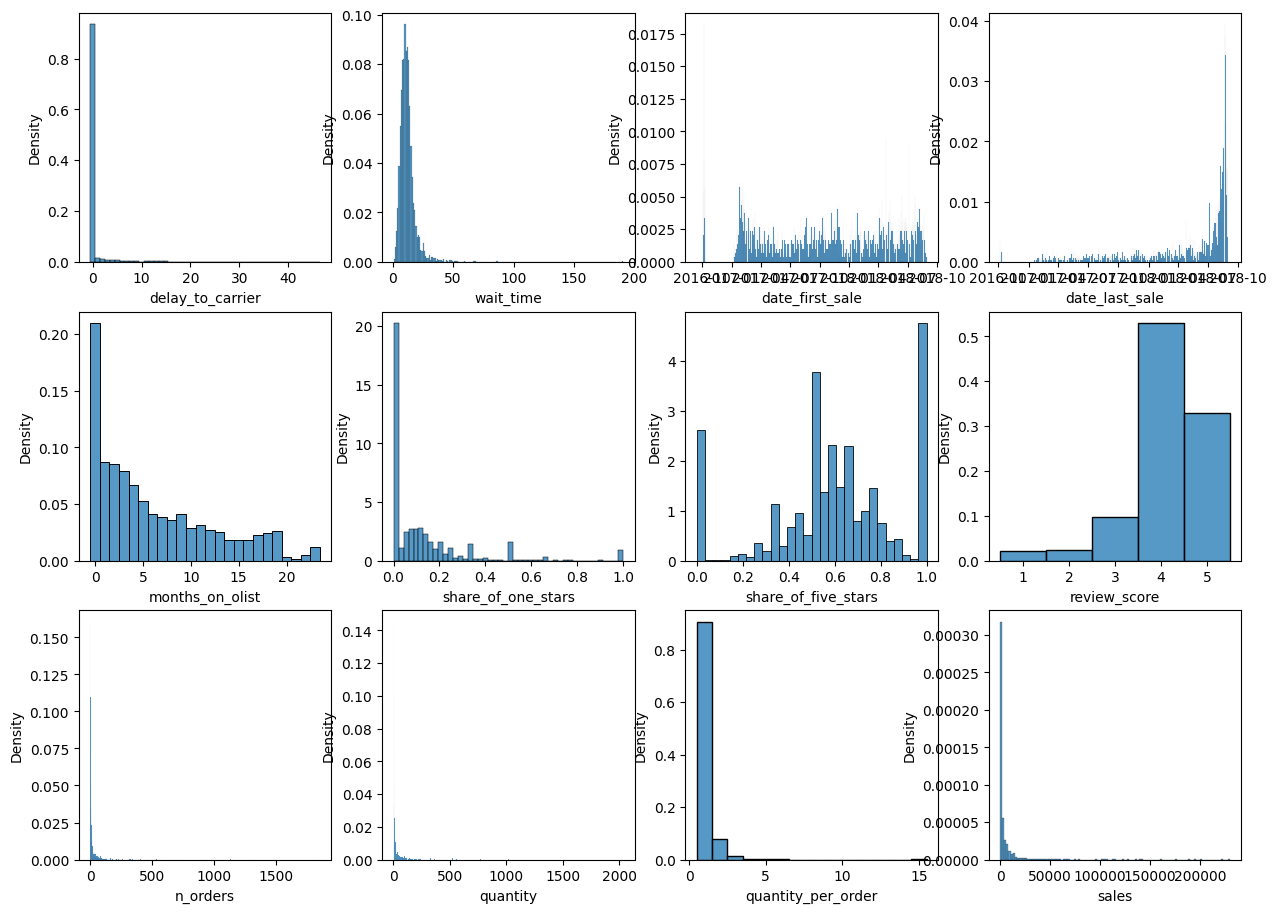

In [22]:
plt.figure(figsize=(15,11))
for (i, col) in enumerate(sellers.describe().columns):#["wait_time", "delay_to_carrier", "avg_review_score", "n_orders", "quantity", "price"]):
    plt.subplot(3,4,i+1)
    sns.histplot(sellers[col], kde=False, stat='density', discrete=[True,None][col in ['share_of_one_stars','share_of_five_stars','sales']]);

💡 Çok düşük değerlendirme puanlarına sahip bir grup satıcının öne çıktığı görünüyor!

📊 Grafiksel olarak inceleyelim:
- `plotly` kullanarak `delay_to_carrier` ile `wait_time` arasındaki ilişkiyi gösteren bir saçılma grafiği (scatterplot) oluşturuyoruz; kabarcık boyutunu satıcının toplam `sales`'i, rengini ise `review_score` belirliyor.

`plotly`'ı daha sonra detaylı göreceğiz; şimdilik aşağıdaki hücreyi çalıştırın.

In [23]:
import plotly.express as px
fig = px.scatter(data_frame = sellers[sellers['review_score'] < 4],
    x="wait_time",
    y="delay_to_carrier",
    size="sales",
    color="review_score",
    size_max = 60,
    opacity = 0.5
)
fig.show()

En kötü satıcıları bulmak için `x`, `y`, `color` ve `size` değerlerini değiştirmekten çekinmeyin.

### (2.2) `review_score`'u OLS ile modelleme

⚠️ Saçılma grafikleri veriyi görsel olarak analiz etmemizi sağlar, fakat sınırlamaları vardır: deneme-yanılma içerir ve ilişkileri yalnızca niteliksel değerlendiririz.

💡 **Satıcıların `review_score`** değişkenini açıklamak için daha sağlam bir yöntem, `statsmodels` içinde **çok değişkenli (multivariate) OLS** kullanarak çeşitli özelliklerin `review_score` üzerindeki etkisini modellemektir.

İstediğiniz sayısal özellikleri kullanarak bir OLS oluşturalım.

👉 Regresyon katsayılarını karşılaştırabilmek için önce aşağıdaki `standardize` fonksiyonunu kullanarak özelliklerinizi standardize edin.

In [24]:
def standardize(df, features):
    """Standardize specified numerical features in a DataFrame using z-score.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    features : list of str
        List of column names to standardize.

    Returns
    -------
    pandas.DataFrame
        A copy of the original dataframe where the specified features have been
        standardized to zero mean and unit variance. Other columns are left
        unchanged.
    """
    df_standardized = df.copy()
    mu = df[features].mean()
    sigma = df[features].std()
    df_standardized[features] = (df[features] - mu) / sigma
    return df_standardized

In [25]:
features = ['wait_time', 'delay_to_carrier', 'months_on_olist', 
            'share_of_one_stars', 'share_of_five_stars', 
            'n_orders', 'quantity', 'quantity_per_order', 'sales']

sellers_standardized = standardize(sellers, features)
sellers_standardized.head()

,seller_id,seller_city,seller_state,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,share_of_one_stars,share_of_five_stars,review_score,n_orders,quantity,quantity_per_order,sales
0,3442f8959a84dea7ee197c632cb2df15,campinas,SP,-0.167974,0.124366,2017-05-05 16:25:11,2017-08-30 12:50:19,-0.347812,1.124912,-0.938949,3.00,-0.285964,-0.287186,-0.357945,-0.306525
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,SP,-0.167974,-0.434800,2017-03-29 02:10:34,2018-06-06 20:15:21,1.295432,-0.375345,0.466068,4.55,0.059240,0.025534,-0.301070,0.502699
2,ce3ad9de960102d0677a81f5d0bb7b2d,rio de janeiro,RJ,-0.167974,-1.145404,2018-07-30 12:44:49,2018-07-30 12:44:49,-1.005109,-0.640097,1.452570,5.00,-0.304624,-0.303645,-0.357945,-0.310802
3,c0f3eea2e14555b6faeea3dd58c1b1c3,sao paulo,SP,-0.167974,-0.915549,2018-08-03 00:44:08,2018-08-03 00:44:08,-1.005109,-0.640097,1.452570,5.00,-0.304624,-0.303645,-0.357945,-0.316299
4,51a04a8a6bdcb23deccc82b0b80742cf,braganca paulista,SP,1.292828,3.278353,2017-11-14 12:15:25,2017-11-14 12:15:25,-1.005109,4.654928,-2.134708,1.00,-0.304624,-0.303645,-0.357945,-0.310098


👉 Sonraki adımda bir OLS modeli oluşturun ve fit edin.

In [26]:
model = smf.ols(formula=f"review_score ~ {'+ '.join(features)}", data=sellers_standardized).fit()

❓ En etkili özellikler hangileri?

👉 Sıralanmış katsayılarla bir 📊 `bar_plot` çizin.

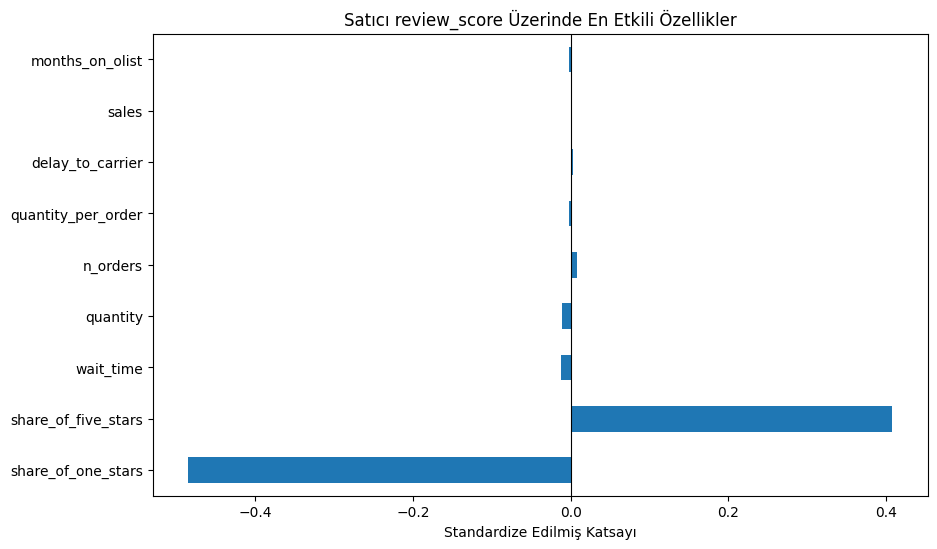

In [27]:
coefs = model.params.drop('Intercept')
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
coefs_sorted.plot(kind='barh')
plt.xlabel('Standardize Edilmiş Katsayı')
plt.title('Satıcı review_score Üzerinde En Etkili Özellikler')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.show()

👉 Son olarak modelinizin performansını (`R-squared`) ve `residuals`'ı inceleyin

In [28]:
print(f"R-squared: {model.rsquared:.4f}")

residuals = model.resid
print(f"Residuals ortalama: {residuals.mean():.6f}")

R-squared: 0.9451
Residuals ortalama: -0.000000


👉 Gerçek değerlendirme puanlarını ve modelin tahmin ettiği puanları aynı grafikte göstererek karşılaştırın.

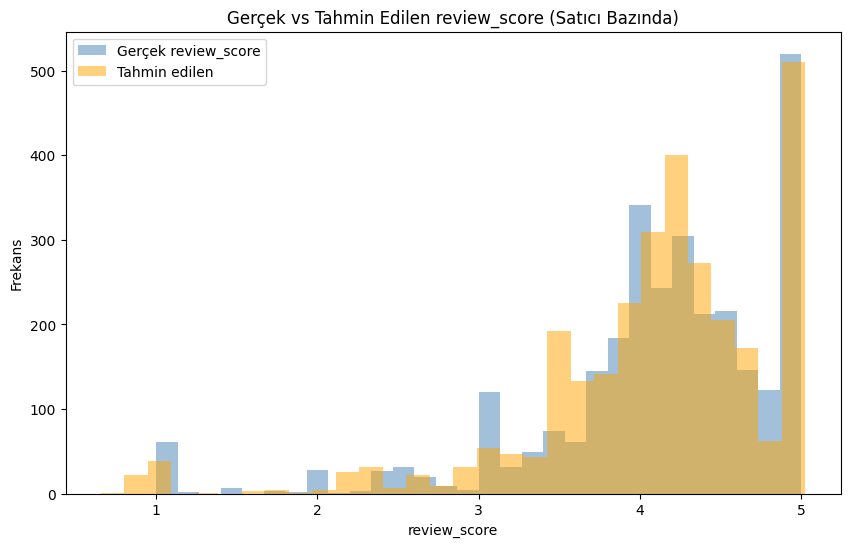

In [29]:
predicted = model.fittedvalues

plt.figure(figsize=(10, 6))
plt.hist(sellers_standardized['review_score'], bins=30, alpha=0.5, label='Gerçek review_score', color='steelblue')
plt.hist(predicted, bins=30, alpha=0.5, label='Tahmin edilen', color='orange')
plt.xlabel('review_score')
plt.ylabel('Frekans')
plt.legend()
plt.title('Gerçek vs Tahmin Edilen review_score (Satıcı Bazında)')
plt.show()

👉 Artıkları (residuals) görselleştirin

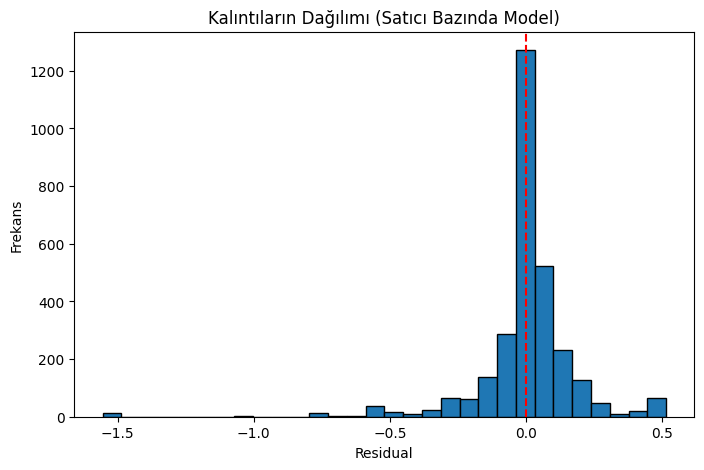

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Frekans')
plt.title('Kalıntıların Dağılımı (Satıcı Bazında Model)')
plt.show()

### (2.3) Analize `seller_state` bilgisini ekleyin

❓ Henüz `seller_state` bilgisini kullanmadık.  
- Sadece `seller_state`'lere karşı `review_score`'u regresyonla modelleyen yeni bir OLS oluşturun.
- `olist/utils.py` içinde sizin için yazılmış olan `return_significative_coef(model)` fonksiyonunu kullanarak anlamlı (significant) özellikleri analiz edin.
- `review_score` açısından en iyi eyaletler hangileri?

<details>
    <summary>- İpuçları -</summary>
        
⚠️ Dikkat, `seller_state` kategorik bir özelliktir. 
    
💡 Formülde kategorik değişkenleri belirtmek için `C(a_cat_feature)` kullanın. Bu, her benzersiz kategori için bir boolean değişken (`is_cat_feature_xx`) oluşturacaktır.

</details>

In [34]:
significative_coefs.sort_values(by='coef', ascending=False)

,variable,p_value,coef
0,Intercept,0.003630,2.333333
16,C(seller_state)[T.RN],0.014751,2.142381
4,C(seller_state)[T.ES],0.011300,2.077548
8,C(seller_state)[T.MS],0.026098,1.954474
11,C(seller_state)[T.PB],0.025835,1.930556
9,C(seller_state)[T.MT],0.035051,1.889815
19,C(seller_state)[T.SC],0.022605,1.833534
14,C(seller_state)[T.PR],0.022771,1.829067
18,C(seller_state)[T.RS],0.024153,1.815430
5,C(seller_state)[T.GO],0.025828,1.810196


☝️ Bazı eyaletlerin ortalama olarak diğerlerinden _anlamlı_ biçimde daha iyi değerlendirmelere sahip olduğu görülebilir.

🤔 Bu, daha düşük `quantity_per_order`, daha kısa `wait_time` veya `delay_to_carrier`'dan mı kaynaklanıyor? Yoksa elimizde olmayan başka faktörlerden mi?

❓ **`seller_state` etkisini diğerlerinden izole etmeye çalışın: OLS modelinize sürekli (continuous) diğer özellikleri ekleyin; `seller_state` artık istatistiksel olarak anlamlı olmayana kadar devam edin!**

In [36]:
model_state_controlled = smf.ols(
    formula="review_score ~ C(seller_state) + wait_time + delay_to_carrier + quantity_per_order",
    data=sellers_standardized
).fit()

significative_coefs_controlled = return_significative_coef(model_state_controlled)
significative_coefs_controlled.sort_values(by='coef', ascending=False)

,variable,p_value,coef
0,Intercept,3.218613e-07,3.706197
24,quantity_per_order,6.193825e-04,-0.045408
23,delay_to_carrier,1.031439e-15,-0.120940
22,wait_time,5.036616e-72,-0.279082


**Sonuç:** `seller_state`'in review_score üzerindeki etkisi, wait_time, delay_to_carrier ve quantity_per_order kontrol edildiğinde istatistiksel olarak anlamlılığını kaybediyor. Bu, coğrafi farkın gerçek nedeninin eyalet değil, o eyaletlerdeki satıcıların lojistik/teslimat performansı olduğunu gösteriyor — klasik bir confounding (karıştırıcı faktör) örneği.

In [ ]:
# YOUR CODE HERE

☝️ Analize `wait_time` ekledikten sonra, 22 adet `is_seller_state_xx` dummy değişkeninin hiçbirinin istatistiksel olarak anlamlı olmadığı görüldü:

Küçük veri setimiz göz önüne alındığında (çoğu eyalette çok az sayıda satıcı var):
- "Bazı eyaletlerin, `wait_time` dışındaki nedenlerle doğal olarak diğerlerinden daha iyi olduğu" sonucuna _varamayız_.
- Başka bir deyişle, "`seller_state`'in `wait_time` dışında `review_score` üzerinde etkisi yoktur" hipotezini reddedemeyiz.

🏁 Tebrikler!

💾 Commit ve push yapın:
- `sellers.ipynb` not defterinizi
- ayrıca `seller.py` dosyanızı